In [583]:
def ngramas (texto, n):
    """Retorna uma lista de n-gramas a partir de um texto e um valor n."""
    texto = texto.replace(" ", "")
    return [texto[i:i+n] for i in range(len(texto)-n+1)]

In [584]:
from collections import Counter
import pandas as pd

def frec_ngramas (texto, n):
    """Retorna las frecuencias de cada n-grama en un texto."""
    ngrams = ngramas(texto, n)
    contagem = Counter(ngrams)
    df = pd.DataFrame(contagem.items(), columns=['n-grama', 'frecuencia'])
    df = df.sort_values(by='frecuencia', ascending=False).reset_index(drop=True)
    return df

funciones auxiliares

In [585]:
def leer_frecuencias (archivo):
    """Lee un archivo CSV con n-gramas y sus frecuencias, y devuelve un DataFrame."""
    df = pd.read_csv(archivo ,sep=' ', names=['n-grama', 'frecuencia'])
    return df

In [586]:
def leer_texto_cifrado (texto_cifrado , n):
    """Lee un texto cifrado y devuelve un DataFrame con las frecuencias de n-gramas."""
    with open(texto_cifrado, 'r') as file:
        texto_cifrado = file.readlines()[0]
    return frec_ngramas(texto_cifrado, n)    
    

Analisis monogramas

In [587]:
monogramas = leer_frecuencias('spanish_monograms.txt')

In [588]:
monogramas.head(10)

,n-grama,frecuencia
0,E,10912000
1,A,10301872
2,O,7398419
3,S,6128524
4,N,5838540
5,I,5694616
6,R,5450913
7,L,4808679
8,D,4237020
9,C,3648080


<Axes: title={'center': 'Frecuencia de Monogramas en Español'}, xlabel='n-grama'>

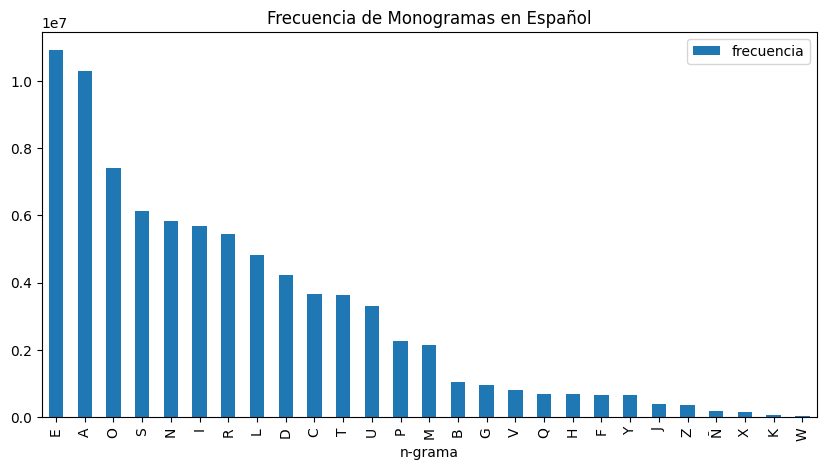

In [589]:
monogramas.plot(x='n-grama', y='frecuencia', kind='bar', figsize=(10, 5), title='Frecuencia de Monogramas en Español')

In [590]:
monogramas_cifrado = leer_texto_cifrado('texto_cifrado.txt', 1)

In [591]:
monogramas_cifrado.head(10)

,n-grama,frecuencia
0,H,2609
1,L,2343
2,X,1710
3,V,1502
4,G,1261
5,F,1242
6,U,1195
7,T,1188
8,K,980
9,A,758


analisis bigramas

In [592]:
bigramas = leer_frecuencias('spanish_bigrams.txt')

In [593]:
bigramas.head(10)   

,n-grama,frecuencia
0,DE,2088635
1,ES,1882962
2,EN,1850294
3,EL,1638128
4,LA,1464005
5,OS,1460757
6,ON,1307790
7,AS,1268034
8,ER,1239281
9,RA,1197125


In [594]:
bigramas_cifrado = leer_texto_cifrado('texto_cifrado.txt', 2)

In [595]:
bigramas_cifrado.head(10)  

,n-grama,frecuencia
0,KL,471
1,HV,437
2,XV,388
3,LF,385
4,LU,378
5,UH,372
6,LV,348
7,LG,310
8,HF,282
9,HK,279


Analisis trigramas

In [596]:
trigramas = leer_frecuencias('spanish_trigrams.txt')

In [597]:
trigramas.head(20) 

,n-grama,frecuencia
0,DEL,601928
1,QUE,594436
2,ENT,538864
3,ION,450424
4,ELA,439787
5,CON,431589
6,SDE,417925
7,ADE,408906
8,CIO,398883
9,NTE,394852


In [598]:
trigramas_cifrado = leer_texto_cifrado('texto_cifrado.txt', 3)

In [599]:
trigramas_cifrado.head(10)

,n-grama,frecuencia
0,BAL,160
1,KLU,159
2,VKL,117
3,HJH,115
4,UXV,111
5,LUH,107
6,UHV,99
7,HKL,97
8,LFC,96
9,XKL,94


In [600]:
alfabeto_permutado = {
    'a': 'u',
    'b': 'q',
    'c': 't',
    'd': 'f',
    'e': 'v',
    'f': 'n',
    'g': 'r',
    'h': 'a',
    'i': 'x',
    'j': 'b',
    'k': 'd',
    'l': 'e',
    'm': 'y',
    'n': 'j',
    'o': 'p',
    'p': 'c',
    'q': 'h',
    'r': 'z',
    's': None,
    't': 'i',
    'u': 'l',
    'v': 's',
    'w': 'g',
    'x': 'o',
    'y': None,
    'z': 'm'
}

Algoritmo de descifrado

In [601]:
def algoritmo_descifrado (texto_cifrado, alfabeto_permutado):
    """Descifra un texto cifrado utilizando un alfabeto permutado."""
    texto_descifrado = ""
    with open(texto_cifrado) as file:
        texto_cifrado = file.readlines()[0]
    for letra in texto_cifrado:
        if not alfabeto_permutado[letra.lower()]:
            texto_descifrado += letra
        else:
            texto_descifrado += alfabeto_permutado[letra.lower()]
    return texto_descifrado

In [602]:
algoritmo_descifrado('texto_cifrado.txt', alfabeto_permutado)

'alrededordelacatedralseextendiaenestrechazonaelprimitivorecintodevetustacomprendialoquesellamabaelbarriodelaencimadaydominabatodoelpuebloquesehabiaidoestirandopornoroesteyporsudestedesdelatorreseveiaenalgunospatiosyjardinesdecasasviejasyruinosasrestosdelaantiguamurallaconvertidosenterradosoparedesmedianerasentrehuertosycorraleslaencimadaeraelbarrionobleyelbarriopobredevetustalosmaslinajudosylosmasandrajososvivianallicercaunosdeotrosaquellosasusanchaslosotrosapinadoselbuenvetustenteeradelaencimadaalgunosfatuosestimabanenmucholapropiedaddeunacasapormiserablequefueraenlapartealtadelaciudadalasombradelacatedralodesantamarialamayorodesanpedrolasdosantiquisimasiglesiasvecinasdelabasilicayparroquiasquesedividianelnobleterritoriodelaencimadaelmagistralveiaasuspieselbarriolinajudocompuestodecaseronesconinfulasdepalaciosconventosgrandescomopueblosytuguriosdondeseamontonabalaplebevetustensedemasiadopobreparapoderhabitarlasbarriadasnuevasallaabajoenelcampodelsolalsudestedondelafabricaviejalevanta